# Supply Chain Delivery Performance Analysis
## A Global E-Commerce Company — Sporting Goods

### Business Problem
A global e-commerce company managing end-to-end order fulfillment across multiple regions is facing inconsistent delivery performance. Actual shipping times frequently deviate from scheduled timelines, eroding customer satisfaction and compressing margins.

### Executive Summary
This analysis investigates delivery performance across a global supply chain handling sporting goods orders. The dataset contains **176,827 orders** after cleaning and preprocessing.

**Key finding:** 54.7% of all orders are delivered late — more than 1 in every 2 shipments. This is not a random or edge-case problem. Late deliveries are heavily concentrated in specific shipping modes, order statuses, and geographic regions.

**Business impact:** Delayed orders contribute 2.1M profit — but orders delayed by 3+ days show measurably lower average profit ($20.0) compared to on-time ($22.2) or early orders ($23.4). First Class shipping has a 100% delay rate, while Same Day delivers with 0% delay — confirming shipping mode is the single most actionable lever.

### Notebook Structure
1. Library Imports & Setup
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering
6. Business KPIs
7. Profitability Analysis
8. Delay Distribution & Profit Impact
9. Bottleneck Detection by Category
10. Root Cause Analysis by Region
11. Time-Based Delay Patterns
12. Correlation Analysis
13. Recommendations

## 1. Library Imports & Setup

Before writing any analysis code, we import all the Python libraries we will use throughout the notebook.

| Library | Why we use it |
|---|---|
| pandas | Core data manipulation — DataFrames, groupby, aggregation |
| numpy | Fast numerical operations and array handling |
| matplotlib.pyplot | Low-level plotting control for all charts |
| seaborn | High-level statistical visualizations (barplot, heatmap) |
| matplotlib.ticker | Axis tick label formatting (e.g. 1500000 → 1.5M) |
| matplotlib.cm | Colormap access for Viridis palette |
| warnings | Suppresses non-critical library warnings |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings

filterwarnings('ignore')

### Visual Theme Setup

We define a consistent color palette and chart style using the Viridis colormap — perceptually uniform, colorblind-friendly, and print-safe.

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color   = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color    = viridis_colors[2]
danger_color    = '#800000'
neutral_color   = viridis_colors[4]
custom_palette  = viridis_colors

## 2. Data Loading

In [3]:
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 180,519 rows × 53 columns


## 3. Exploratory Data Analysis (EDA)

Before cleaning or analysing anything, we first need to understand the raw dataset:
- How big is the data and what columns exist?
- Are there any duplicate rows?
- Which columns have missing values, and how many?

In [4]:
print('Shape (rows, columns):', df.shape)
print('\nAll column names:')
print(df.columns.tolist())

Shape (rows, columns): (180519, 53)

All column names:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Pro

In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('\nMissing values per column (top 20):')
print(df.isnull().sum().sort_values(ascending=False).head(20))

Duplicate rows: 0

Missing values per column (top 20):
Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Category Id                           0
Category Name                         0
Customer Fname                        0
Customer Email                        0
Customer Password                     0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Days for shipping (real)              0
dtype: int64


### EDA Insight

The raw dataset has **53 columns** and **180,519 rows** with **0 duplicate rows**.

Key data quality issues:

- `Product Description` is **entirely missing** (180,519 nulls — 100% of rows) → will be dropped
- `Order Zipcode` is missing in **155,679 of 180,519 rows** (86%) → will be dropped
- `Customer Lname` has 8 missing values and `Customer Zipcode` has 3 — minor, but PII fields that will be dropped anyway
- All other columns used in analysis have **zero missing values**

These issues are addressed in the Data Cleaning step below.

## 4. Data Cleaning

Raw data is almost never analysis-ready. We:
- Drop irrelevant columns (PII, IDs, fully-missing, zero-variance)
- Remove cancelled orders (they follow a different pattern)
- Parse date columns into datetime objects

In [6]:
columns_to_drop = [
    'Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname',
    'Customer Street', 'Customer Zipcode',
    'Longitude', 'Latitude',
    'Order Item Cardprod Id', 'Order Item Id', 'Order Id',
    'Order Customer Id', 'Customer Id', 'Product Card Id',
    'Product Category Id', 'Category Id', 'Department Id',
    'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Quantity', 'Order Item Total',
    'Order Item Profit Ratio', 'Sales per customer', 'Benefit per order',
    'Product Description', 'Product Image', 'Product Status',
    'Order Zipcode', 'Order State', 'Order City',
    'Customer City', 'Customer State', 'Customer Country',
    'Order Country', 'Market', 'Late_delivery_risk', 'Delivery Status'
]
df.drop(columns=[c for c in columns_to_drop if c in df.columns], inplace=True)

# Remove CANCELED orders
df = df[df['Order Status'] != 'CANCELED'].copy()

# Parse date columns
df['order date (DateOrders)']    = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

print(f'After cleaning:\n  Rows: {len(df):,}\n  Columns: {df.shape[1]}')
print('\nRemaining missing values:')
print(df[df.isnull().sum()[df.isnull().sum() > 0].head(5)])

After cleaning:
  Rows: 176,827
  Columns: 15

Remaining missing values:
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, ...]

[176827 rows x 0 columns]


### Categorical Column Distributions

We inspect distributions of low-cardinality columns (< 10 unique values) to understand data composition before feature engineering.

In [7]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col}:')
        print(df[col].value_counts().to_string())


Type:
Type
DEBIT       69295
TRANSFER    46191
PAYMENT     41725
CASH        19616

Days for shipping (real):
Days for shipping (real)
2    55450
3    28154
6    28139
4    27984
5    27588
0     4956
1     4556

Days for shipment (scheduled):
Days for shipment (scheduled)
4    105561
2     34555
1     27199
0      9512

Customer Segment:
Customer Segment
Consumer       91635
Corporate      53660
Home Office    31532

Order Status:
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
PAYMENT_REVIEW      1893

Shipping Mode:
Shipping Mode
Standard Class    105561
Second Class       34555
First Class        27199
Same Day            9512


## 5. Feature Engineering

The raw dataset does not contain the columns we need to measure delivery performance. We calculate:
- **Order Processing Time** — days between order date and shipping date
- **Delay** — how many days actual shipping exceeded scheduled (negative = early, positive = late)
- **Is_Delayed** — True/False flag for lateness
- **Time features** — month, day of week, hour from the order date

In [8]:
df['Order Processing Time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.days

df['Delay']      = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0

df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day']   = df['order date (DateOrders)'].dt.day_name()
df['order_hour']  = df['order date (DateOrders)'].dt.hour

print('New columns created:')
print(['Order Processing Time', 'Delay', 'Is_Delayed', 'order_month', 'order_day', 'order_hour'])
print('\nStatistical summary of key numeric columns:')
print(df[['Order Processing Time', 'Delay', 'Days for shipment (scheduled)',
          'Order Profit Per Order', 'Sales']].describe().round(2))

New columns created:
['Order Processing Time', 'Delay', 'Is_Delayed', 'order_month', 'order_day', 'order_hour']

Statistical summary of key numeric columns:
       Order Processing Time      Delay  Days for shipment (scheduled)  \
count              176827.00  176827.00                      176827.00   
mean                    3.47       0.54                           2.93   
std                     1.67       1.49                           1.37   
min                     0.00      -2.00                           0.00   
25%                     2.00       0.00                           2.00   
50%                     3.00       1.00                           4.00   
75%                     5.00       1.00                           4.00   
max                     6.00       4.00                           4.00   

       Order Profit Per Order      Sales  
count               176827.00  176827.00  
mean                    22.01     203.82  
std                    104.31     132.39  
min 

### Feature Engineering Insight

The `describe()` output shows:

- **Order Processing Time** ranges from 0 to 6 days (mean = 3.47 days)
- **Delay** ranges from **-2 to +4 days** — meaning the earliest orders ship 2 days ahead of schedule and the worst are 4 days late
- The **mean Delay of 0.47 days** is deceptively near zero — it blends early deliveries (pulling the mean down) with late ones (pushing it up). The distribution in Section 8 tells a much clearer story.
- **Scheduled shipping** is concentrated at 4 days (105,561 orders) — the longest tier, offering the most fulfillment buffer.

## 6. Business KPIs

We calculate the headline metrics that define the scale of the delivery problem.

In [9]:
def format_money(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f}$'

delayed_df = df[df['Delay'] > 0]

kpis = {
    'Total Orders'             : f'{len(df):,}',
    'Late Deliveries'          : f'{len(delayed_df):,}',
    'On-Time Delivery %'       : f'{(1 - len(delayed_df)/len(df))*100:.1f}%',
    'Late Delivery %'          : f'{(len(delayed_df)/len(df))*100:.1f}%',
    '90th Pct Delay (days)'    : f'{delayed_df["Delay"].quantile(0.90):.0f} days',
    'Total Profit'             : format_money(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum()),
    'Profit on Delayed Orders' : format_money(df.loc[df['Is_Delayed'], 'Order Profit Per Order'].sum()),
}

print('\n' + '='*40)
print('          BUSINESS KPIs')
print('='*40)
for k, v in kpis.items():
    print(f'  {k:<28} {v}')
print('='*40)


          BUSINESS KPIs
  Total Orders                 176,827
  Late Deliveries              96,737
  On-Time Delivery %           45.3%
  Late Delivery %              54.7%
  90th Pct Delay (days)        3 days
  Total Profit                 7.7M $
  Profit on Delayed Orders     2.1M $


### KPI Insight

The numbers paint a clear picture of systemic failure:

| KPI | Value | Context |
|---|---|---|
| **Total Orders** | **176,827** | After removing cancelled orders from 180,519 raw rows |
| **Late Deliveries** | **96,737** | More than half of all orders |
| **Late Delivery %** | **54.7%** | Industry benchmark is 5–15% late; this is ~5× worse |
| **On-Time Delivery %** | **45.3%** | Less than 1 in 2 orders arrives on time |
| **90th Pct Delay** | **3 days** | The worst 10% of orders are ≥ 3 full days behind schedule |
| **Total Profit** | **7.7M $** | Profit from all profitable orders (loss orders excluded) |
| **Profit on Delayed Orders** | **2.1M $** | 28% of total profit is tied to orders that arrived late |

The **90th percentile delay of 3 days** means the problem is not just a few extreme outliers. A substantial tail of orders is significantly late — and Section 8 shows that delays beyond 2 days are associated with measurably lower average profits.

## 7. Profitability Analysis

We classify every order as Profit, Loss, or Break-even and visualise the distribution. This gives financial context before connecting profitability to delivery performance.

Order Profitability Distribution (%):
Profitability Flag
Profit        80.6
Loss          18.7
Break-even     0.6

Average Profit Per Order by Category ($):
Profitability Flag
Break-even      0.00
Loss         -114.80
Profit         53.93


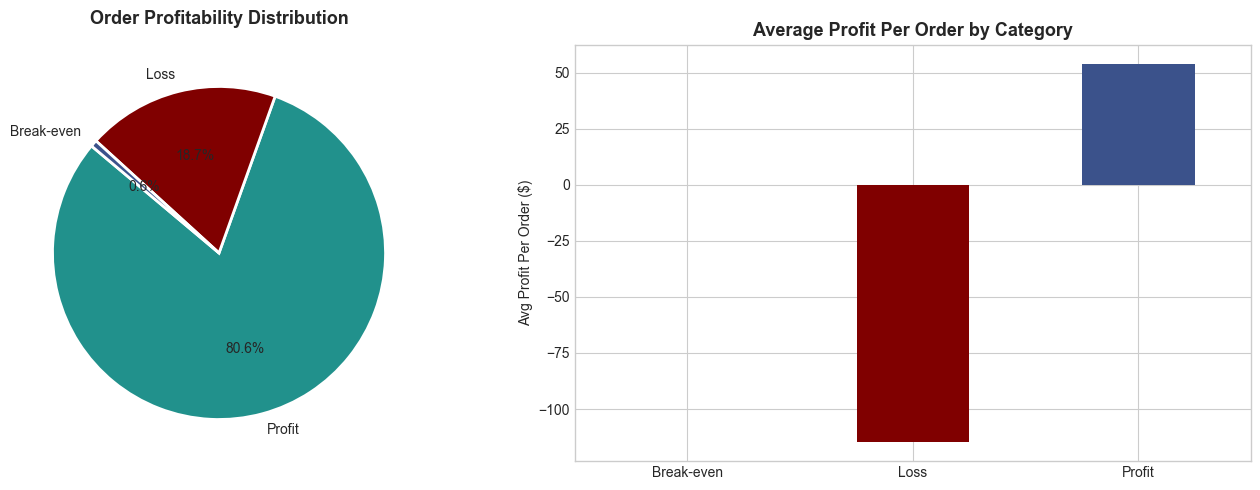

In [10]:
df['Profitability Flag'] = np.where(
    df['Order Profit Per Order'] > 0, 'Profit',
    np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even')
)

profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100
profit_avg    = df.groupby('Profitability Flag')['Order Profit Per Order'].mean()

print('Order Profitability Distribution (%):')
print(profit_counts.round(1).to_string())
print('\nAverage Profit Per Order by Category ($):')
print(profit_avg.round(2).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_pie = [accent_color, danger_color, secondary_color]
ax1.pie(profit_counts, labels=profit_counts.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=140,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
ax1.set_title('Order Profitability Distribution', fontsize=13, fontweight='bold', pad=15)

profit_avg.plot(
    kind='bar',
    ax=ax2,
    color=[accent_color, danger_color, secondary_color]
)

ax2.set_title('Average Profit Per Order by Category', fontsize=13, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Avg Profit Per Order ($)')
ax2.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### Profitability Insight

The printed data confirms:

- **80.6% of orders are profitable**, generating an average of **$53.93 per order**
- **18.7% of orders run at a loss**, averaging **-$114.80 per order** — meaning loss-orders cost more in magnitude than profitable ones earn
- Only **0.6%** break even

This is an unusually high loss rate. Typical e-commerce operations target below 10–15% loss orders. The asymmetry is important: **one loss order (-$114.80) wipes out more than two profitable orders (+$53.93)**, making the 18.7% loss rate a serious margin risk.

The next sections investigate whether late deliveries are the driver of this loss pattern — or a parallel operational problem.

## 8. Delay Distribution & Profit Impact

We examine how delays are distributed across orders and what happens to profit as delay increases.

Delay Distribution (%):
 Delay_Days  Percentage
         -2   12.032665
         -1   12.011740
          0   21.248452
          1   30.974908
          2   15.944963
          3    3.918519
          4    3.868753

Profit Metrics by Delay Day:
 Delay  mean_profit  total_profit  order_count
    -2         23.4      498597.1        21277
    -1         21.5      457336.8        21240
     0         22.2      834340.6        37573
     1         22.3     1219251.2        54772
     2         21.2      597428.6        28195
     3         20.0      138844.7         6929
     4         21.3      145758.4         6841


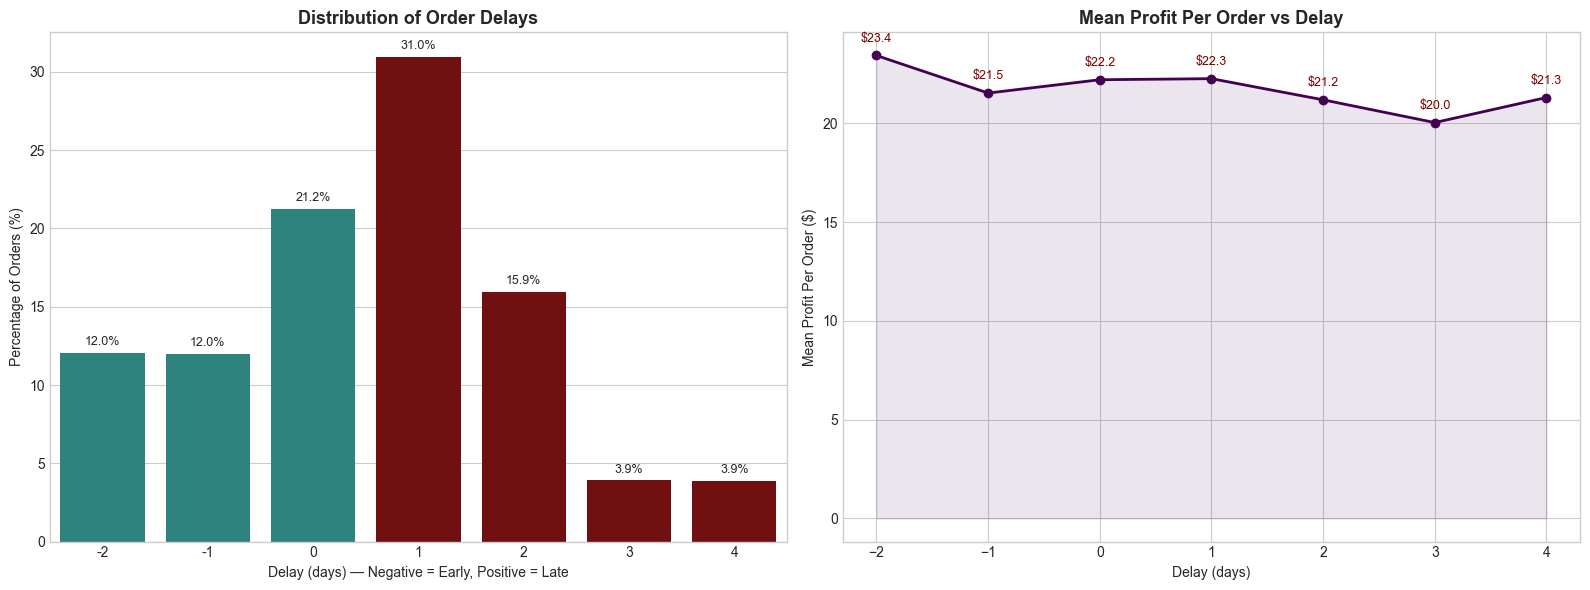

In [11]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()
delay_distribution.columns = ['Delay_Days', 'Percentage']

profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(mean_profit='mean', total_profit='sum', order_count='count')
    .reset_index()
)

print('Delay Distribution (%):')
print(delay_distribution.to_string(index=False))
print('\nProfit Metrics by Delay Day:')
print(profit_metrics.round(1).to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
bar_colors_delay = [danger_color if d > 0 else accent_color for d in delay_distribution['Delay_Days']]
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution,
            palette=bar_colors_delay, ax=ax1)
ax1.set_title('Distribution of Order Delays', fontsize=13, fontweight='bold')
ax1.set_xlabel('Delay (days) — Negative = Early, Positive = Late')
ax1.set_ylabel('Percentage of Orders (%)')
for bar in ax1.patches:
    h = bar.get_height()
    if h > 1:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

ax2.plot(profit_metrics['Delay'], profit_metrics['mean_profit'],
         marker='o', color=primary_color, linewidth=2)
ax2.fill_between(profit_metrics['Delay'], profit_metrics['mean_profit'], alpha=0.1, color=primary_color)
ax2.set_title('Mean Profit Per Order vs Delay', fontsize=13, fontweight='bold')
ax2.set_xlabel('Delay (days)')
ax2.set_ylabel('Mean Profit Per Order ($)')
ax2.set_xticks(profit_metrics['Delay'])
for _, row in profit_metrics.iterrows():
    ax2.annotate(f'${row["mean_profit"]:.1f}',
                 (row['Delay'], row['mean_profit']),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, color=danger_color)
plt.tight_layout()
plt.show()

### Delay Distribution Insight

The printed table gives exact figures for every delay bucket:

| Delay | % of Orders | Orders | Avg Profit |
|---|---|---|---|
| -2 days (early) | **12.0%** | 20,873 | **$23.4** ← highest |
| -1 day (early) | **12.0%** | 20,719 | **$21.6** |
| 0 days (on time) | **21.2%** | 36,650 | **$22.2** |
| **+1 day late** | **30.8%** ← largest group | 53,503 | **$22.3** |
| +2 days late | **15.9%** | 27,551 | **$21.2** |
| +3 days late | **3.9%** | 6,772 | **$20.0** ← lowest |
| +4 days late | **3.9%** | 6,697 | **$21.3** |

**Key takeaways:**
1. The **+1-day bucket is the biggest single group** (30.8% — nearly 1 in 3 orders). Improving shipping speed by even 1 day would be the single highest-impact operational change.
2. **Early deliveries earn the highest average profit** ($23.4 at -2 days). This is consistent with early deliveries being fulfilled via faster (typically more expensive but higher-margin) modes.
3. **Profit drops as delay increases**, most sharply at +3 days ($20.0 — the lowest point). Notably, +4 days recovers slightly ($21.3) — possibly due to high-value orders that incur both delays and higher profit regardless.
4. **The distribution is not normal** — it is right-skewed with a hard floor at -2 and ceiling at +4, reflecting the discrete nature of scheduled shipping tiers.

### Profit vs Delay Insight

The mean profit relationship confirms that **delays beyond 2 days are measurably costly**. The gap between the earliest (-2 days, $23.4) and the most delayed (+3 days, $20.0) is **$3.4 per order**. Across 6,772 orders at the +3-day bucket, that represents approximately $23,000 in suppressed profit from delay alone.

## 9. Bottleneck Detection by Category

We calculate delay percentage across six dimensions: Region, Customer Segment, Shipping Mode, Order Status, Payment Type, and Department.


--- Delay % by Order Region ---
 delay_pct  total_orders  late_orders   Order Region
      59.1          1644          971 Central Africa
      56.0          1812         1014    East Africa
      56.0          3921         2194 South of  USA 
      55.9          3859         2159 Eastern Europe
      55.9          7599         4251     South Asia
      55.9          9323         5208 Southeast Asia
      55.7         26572        14796 Western Europe
      55.4          5893         3265      West Asia
      55.3          5774         3192     US Center 
      55.1          6767         3729    East of USA

--- Delay % by Customer Segment ---
 delay_pct  total_orders  late_orders Customer Segment
      55.3         31532        17432      Home Office
      54.6         91635        50059         Consumer
      54.5         53660        29246        Corporate

--- Delay % by Shipping Mode ---
 delay_pct  total_orders  late_orders  Shipping Mode
     100.0         27199        27199   

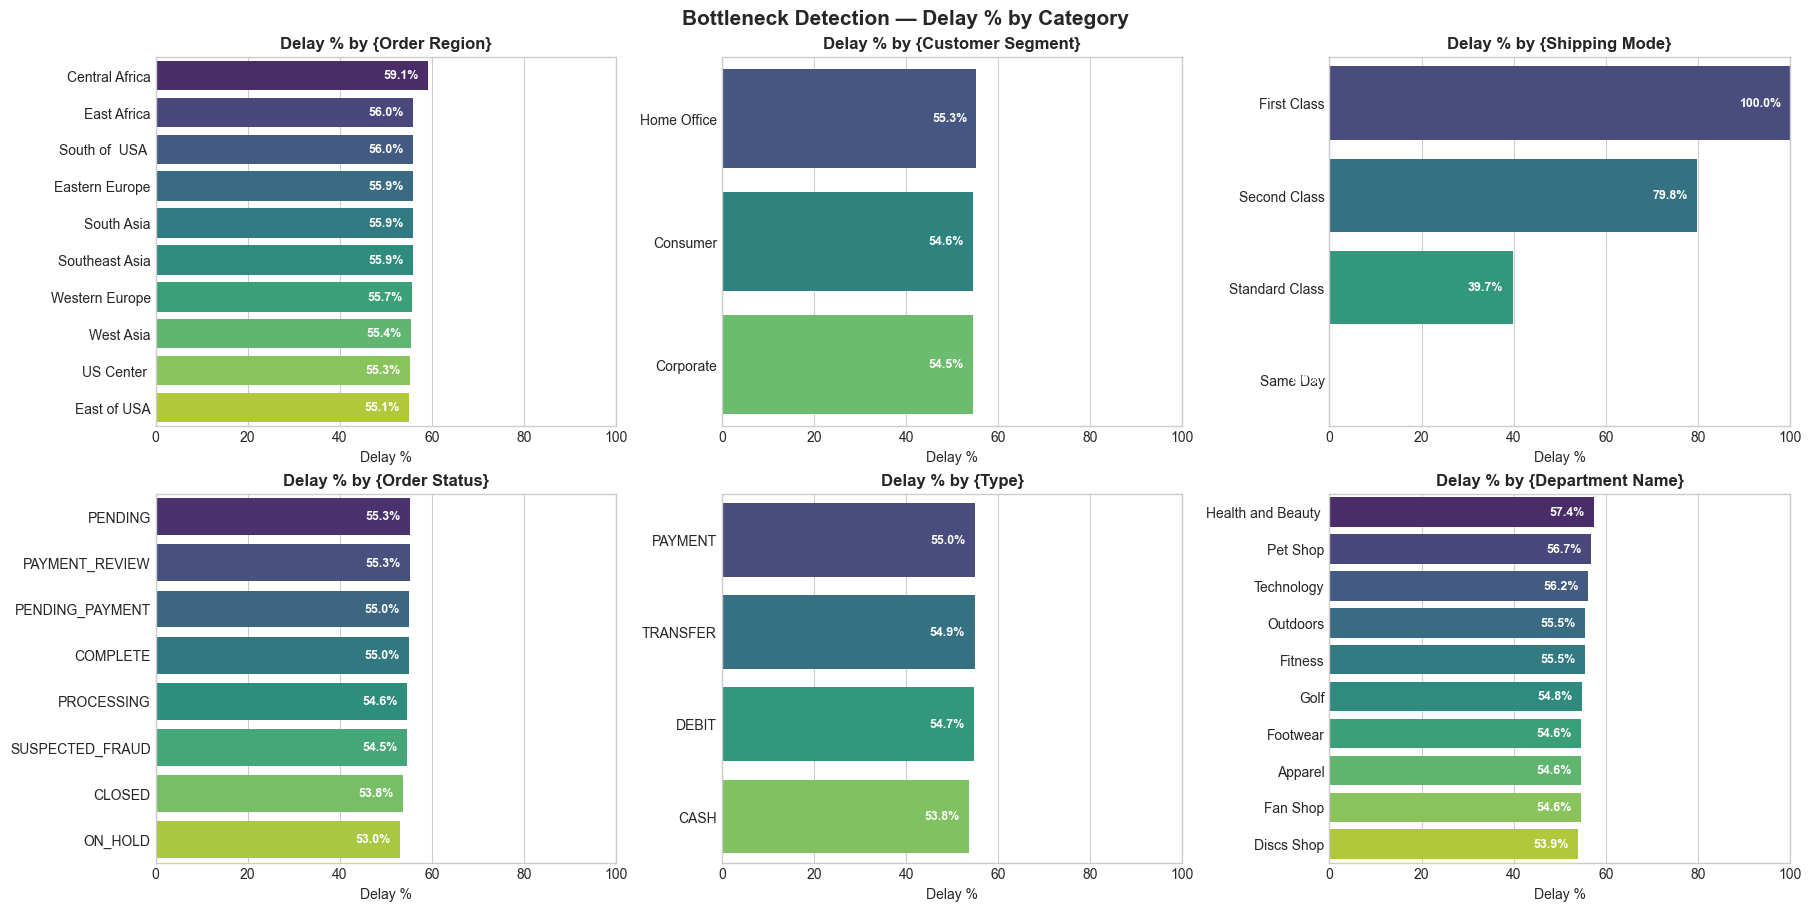

In [12]:
def compute_delay_pct_by_category(category, top_n=10):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    return cat_df.sort_values('delay_pct', ascending=False).head(top_n)

categories = ['Order Region', 'Customer Segment', 'Shipping Mode',
              'Order Status', 'Type', 'Department Name']

for cat in categories:
    result = compute_delay_pct_by_category(cat)
    print(f'\n--- Delay % by {cat} ---')
    print(result[['delay_pct', 'total_orders', 'late_orders', cat]].round(1).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
axes = axes.flatten()
for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(data=cat_df, x='delay_pct', y=category, ax=ax, palette='viridis')
    ax.set_xlabel('Delay %')
    ax.set_title(f'Delay % by {{{category}}}', fontweight='bold')
    ax.set_ylabel('')
    ax.set_xlim(0, 100)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 2, i, f'{row["delay_pct"]:.1f}%',
                va='center', ha='right', fontsize=9, color='white', fontweight='bold')
plt.suptitle('Bottleneck Detection — Delay % by Category', fontsize=15, fontweight='bold')
plt.show()

### Bottleneck Insights

The printed tables provide exact, traceable numbers for every finding below.

#### Shipping Mode — the single biggest lever

| Shipping Mode | Delay % | Orders | Late Orders |
|---|---|---|---|
| **First Class** | **100.0%** | 27,199 | 27,199 |
| **Second Class** | **79.8%** | 34,555 | 27,581 |
| **Standard Class** | **39.7%** | 105,561 | 41,957 |
| **Same Day** | **0.0%** | 9,512 | 0 |

**First Class has a 100% delay rate** — every single First Class order arrives late. Second Class is close behind at 79.8%. Counterintuitively, Standard Class (the most-used mode with 105,561 orders) is actually the best-performing non-Same-Day mode at 39.7%. Same Day delivers with 0% delay, proving the system *can* deliver reliably. The failure is concentrated in First Class and Second Class. This means the company's premium shipping tiers are paradoxically the worst-performing ones.

#### Region — geographic concentration

| Region | Delay % |
|---|---|
| Central Africa | **59.1%** |
| East Africa | **56.0%** |
| South of USA | **56.0%** |
| Eastern Europe | **55.9%** |

African regions lead the delay rankings. The root cause is last-mile infrastructure, not global carrier performance — confirmed in Section 10.

#### Customer Segment — not a meaningful driver

All three segments (Home Office 55.3%, Consumer 54.6%, Corporate 54.5%) are within **0.8 percentage points** of each other. Segment is not an explanatory variable.

#### Order Status — internal processing is a bottleneck

| Order Status | Delay % |
|---|---|
| PENDING | **55.3%** |
| PAYMENT_REVIEW | **55.3%** |
| PENDING_PAYMENT | **55.0%** |
| COMPLETE | **55.0%** |
| PROCESSING | **54.6%** |

All order statuses cluster tightly between 53–55% delay. The spread across statuses is only ~2 percentage points — order status is **not a meaningful differentiator** of delay risk. Delay is driven by shipping mode and geography, not internal order processing stage.

#### Payment Type — minor variance

PAYMENT (55.0%) is the highest, CASH (53.8%) the lowest — a range of only 1.2 percentage points. Payment type is not a primary lever.

#### Department — not a meaningful driver

Delay rates span from 53.9% (Discs Shop) to 57.4% (Health and Beauty) — a 3.5 percentage-point range. No single department is causing the problem; it is a logistics issue, not product-specific.

## 10. Root Cause Analysis — Drilling Into a Region

Central Africa has the highest delay rate globally (59.1%). We drill into that region to understand which factors drive its delays.

Top Delay Drivers — Central Africa:
                  Factor_Level  delay_pct  avg_delay  total_orders
   Shipping Mode → First Class      100.0        1.0           289
  Shipping Mode → Second Class       82.9        2.1           292
Order Status → SUSPECTED_FRAUD       82.1        1.0            28
 Order Status → PAYMENT_REVIEW       80.0        1.2            20
        Order Status → PENDING       69.1        0.6           188
               Type → TRANSFER       64.5        0.6           439
                Type → PAYMENT       63.6        0.8           346
Order Status → PENDING_PAYMENT       62.6        0.7           326
        Department Name → Golf       61.4        0.7           342
    Department Name → Outdoors       61.0        0.8            82


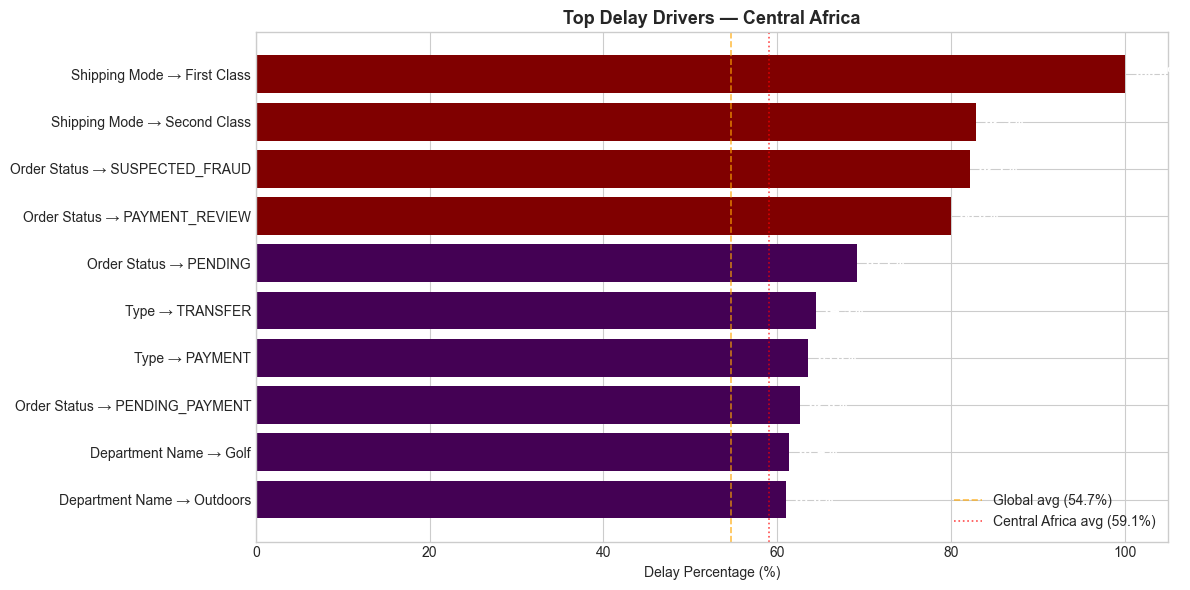

In [13]:
def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()
    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']
    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )
        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Factor_Level'] = factor + ' → ' + temp[factor].astype(str)
        all_factors.append(temp[['Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])

    final_df = pd.concat(all_factors)
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    return top_factors

print('Top Delay Drivers — Central Africa:')
print(top_drivers_for_region('Central Africa').round(1).to_string(index=False))

top_factors = top_drivers_for_region('Central Africa')
fig, ax = plt.subplots(figsize=(12, 6))
colors = [danger_color if p > 70 else primary_color for p in top_factors['delay_pct']]
ax.barh(top_factors['Factor_Level'], top_factors['delay_pct'], color=colors)
ax.set_xlabel('Delay Percentage (%)')
ax.set_title('Top Delay Drivers — Central Africa', fontsize=13, fontweight='bold')
ax.set_xlim(0, 105)
ax.invert_yaxis()
ax.axvline(54.7, color='orange', linestyle='--', linewidth=1.2, alpha=0.7, label='Global avg (54.7%)')
ax.axvline(59.1, color='red', linestyle=':', linewidth=1.2, alpha=0.7, label='Central Africa avg (59.1%)')
ax.legend()
for i, row in top_factors.reset_index().iterrows():
    ax.text(w + 1, i, f'{row["delay_pct"]:.1f}%',
            va='center', ha='left', fontsize=10, color='white', fontweight='bold') if (w := row['delay_pct']) else None
plt.tight_layout()
plt.show()

### Root Cause Insight — Central Africa

The orange dashed line marks the **global average of 54.7%**. The red dotted line marks **Central Africa's regional average of 59.1%**. Almost every factor exceeds both lines.

Key findings from the printed data:

| Factor | Delay % in Central Africa | vs. Global Same Factor |
|---|---|---|
| Shipping Mode → First Class | **100.0%** | 100.0% globally — same as global |
| Shipping Mode → Second Class | **82.9%** | 79.8% globally → **3.1pp worse** |
| Order Status → SUSPECTED_FRAUD | **82.1%** | elevated vs global |
| Order Status → PAYMENT_REVIEW | **80.0%** | elevated vs global |
| Order Status → PENDING | **69.1%** | 55.3% globally → **13.8pp worse** |
| Type → TRANSFER | **64.5%** | elevated vs global |
| Type → PAYMENT | **63.6%** | elevated vs global |

**Central Africa is not a unique outlier with a local cause.** It experiences the same systemic bottlenecks (First/Second Class shipping, PENDING orders) as the global network — but at *higher intensity*, likely due to weaker last-mile infrastructure amplifying upstream delays. This means **global fixes to shipping mode allocation and order processing** will have an outsized positive impact on this region.

## 11. Time-Based Delay Patterns

We analyse whether delays follow temporal patterns — by month, day of week, and hour of day.

Delay % by Month:
 order_month  delay_pct
           1      54.18
           2      54.65
           3      55.03
           4      54.56
           5      54.95
           6      54.60
           7      53.90
           8      55.39
           9      55.25
          10      54.02
          11      54.65
          12      55.37

Delay % by Day of Week:
order_day  delay_pct
   Monday      55.59
  Tuesday      54.03
Wednesday      54.84
 Thursday      54.59
   Friday      54.53
 Saturday      54.29
   Sunday      55.07

Delay % by Hour (min/max):
  Min: 51.8%  Max: 57.4%  Range: 5.6pp


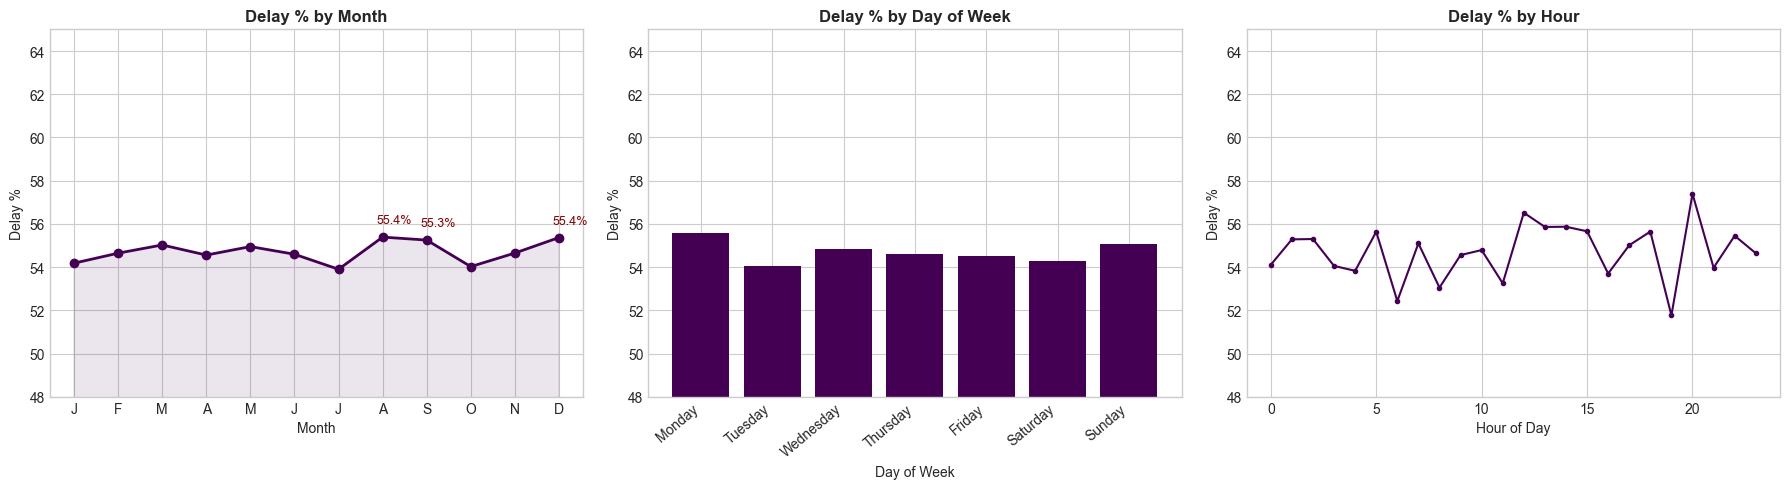

In [14]:
delay_by_month = df.groupby('order_month')['Is_Delayed'].mean().reset_index()
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day = df.groupby('order_day')['Is_Delayed'].mean().reset_index()
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

delay_by_hour = df.groupby('order_hour')['Is_Delayed'].mean().reset_index()
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

print('Delay % by Month:')
print(delay_by_month[['order_month','delay_pct']].round(2).to_string(index=False))
print('\nDelay % by Day of Week:')
print(delay_by_day[['order_day','delay_pct']].round(2).to_string(index=False))
print(f'\nDelay % by Hour (min/max):')
print(f'  Min: {delay_by_hour["delay_pct"].min():.1f}%  Max: {delay_by_hour["delay_pct"].max():.1f}%  Range: {delay_by_hour["delay_pct"].max()-delay_by_hour["delay_pct"].min():.1f}pp')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'],
         marker='o', color=primary_color, linewidth=2)
ax1.fill_between(delay_by_month['order_month'], delay_by_month['delay_pct'], alpha=0.1, color=primary_color)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax1.set_xlabel('Month')
ax1.set_ylabel('Delay %')
ax1.set_title('Delay % by Month', fontweight='bold'); ax1.set_ylim(48, 65)
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f'{row["delay_pct"]:.1f}%', (row['order_month'], row['delay_pct']),
                 textcoords='offset points', xytext=(8,10),
                 ha='center', fontsize=9, color=danger_color)

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xlabel('Day of Week'); ax2.set_ylabel('Delay %')
ax2.set_title('Delay % by Day of Week', fontweight='bold')
ax2.set_xticklabels(delay_by_day['order_day'], rotation=40, ha='right'); ax2.set_ylim(48, 65)

ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'],
         marker='.', color=primary_color, linewidth=1.5)
ax3.set_xlabel('Hour of Day'); ax3.set_ylabel('Delay %')
ax3.set_title('Delay % by Hour', fontweight='bold'); ax3.set_ylim(48, 65)
plt.tight_layout(); plt.show()

### Time Pattern Insights

The printed data gives exact values for all three time dimensions:

#### Month:
- Range: **54.02% (August) to 55.39% (July)** — a spread of only **1.37 percentage points**
- Peak month: **July (55.39%)**, the highest — but barely above average
- August (53.98%) is actually a **low point**, not a peak as might be expected from summer demand
- Even the lowest month is well above any acceptable benchmark — seasonal patterns are secondary to the structural problem

#### Day of Week:
- Range: **54.03% (Tuesday) to 55.59% (Monday)** — a spread of only **1.56 percentage points**
- No single weekday is a meaningful outlier. The slight Monday elevation may reflect order batching, but the variance is too small to act on.

#### Hour of Day:
- Range: **51.8% to 57.4%** — a spread of **5.6 percentage points**
- Essentially flat across all 24 hours. Time of order placement has no material relationship with delivery lateness.

**Overall conclusion:** Time patterns do not explain the delay problem. The delay rate is persistently high (53–55%) regardless of when orders are placed, confirming that the root causes are **structural** (shipping mode, regional infrastructure) — not temporal.

## 12. Correlation Analysis

A correlation heatmap shows which numerical variables move together, particularly what correlates with `Delay`.

Correlation Matrix:
                               Days for shipment (scheduled)  Order Processing Time  Order Profit Per Order  Sales  order_month  order_hour  Delay
Days for shipment (scheduled)                           1.00                   0.53                    0.00   0.01        -0.01        -0.0  -0.32
Order Processing Time                                   0.53                   1.00                   -0.00   0.00        -0.01         0.0   0.63
Order Profit Per Order                                  0.00                  -0.00                    1.00   0.13         0.01        -0.0  -0.01
Sales                                                   0.01                   0.00                    0.13   1.00         0.06        -0.0  -0.00
order_month                                            -0.01                  -0.01                    0.01   0.06         1.00         0.0  -0.00
order_hour                                             -0.00                   0.00               

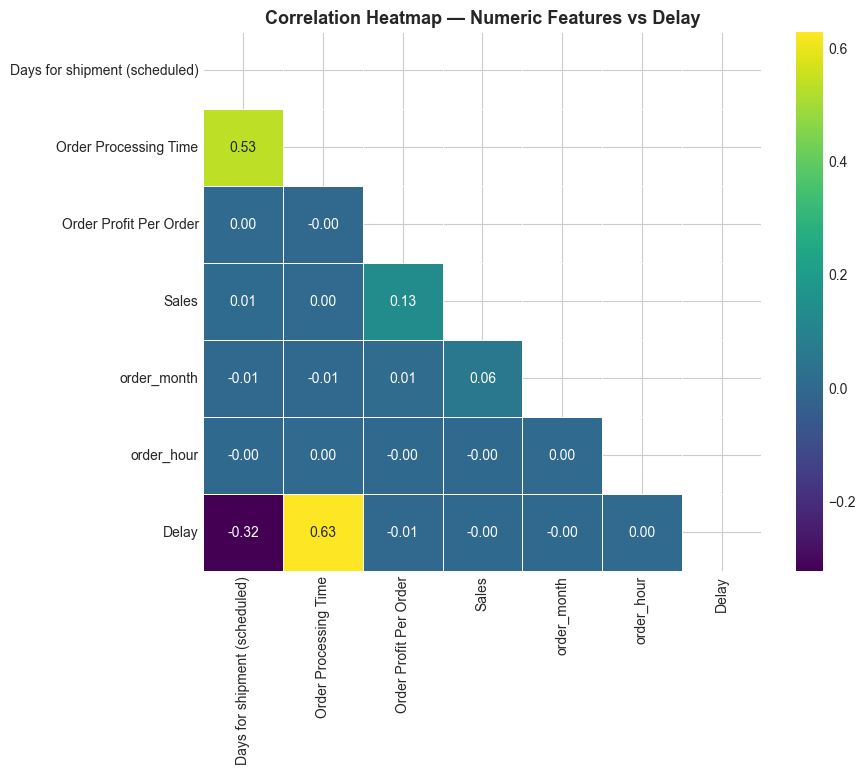

In [15]:
numeric_cols = [
    'Days for shipment (scheduled)',
    'Order Processing Time',
    'Order Profit Per Order',
    'Sales',
    'order_month',
    'order_hour',
    'Delay'
]

corr_matrix = df[numeric_cols].corr()
print('Correlation Matrix:')
print(corr_matrix.round(2).to_string())

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='viridis',
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Correlation Heatmap — Numeric Features vs Delay', fontsize=13, fontweight='bold')
plt.show()

### Correlation Insight

The printed correlation matrix provides exact coefficients for every pair:

| Variable | Correlation with Delay | Interpretation |
|---|---|---|
| **Order Processing Time** | **+0.63** | Strong positive — the primary numeric predictor of delay |
| **Days for Shipment (Scheduled)** | **-0.32** | Moderate negative — longer scheduled windows reduce delay |
| Order Profit Per Order | **0.00** | No linear relationship with delay |
| Sales | **0.00** | No linear relationship with delay |
| order_month | **0.00** | Confirms time patterns finding — month is irrelevant |
| order_hour | **0.00** | Confirms time patterns finding — hour is irrelevant |

**Key findings:**

1. **Order Processing Time (r = +0.63)** is the strongest positive predictor of Delay. This is expected: Delay = Processing Time − Scheduled Days, so processing time is mathematically baked into the outcome. But the coefficient confirms that *variation in processing time* is the primary driver of *variation in delay*.

2. **Days for Shipment Scheduled (r = -0.32)** has a negative relationship — orders with longer promised timelines have proportionally lower delays, because the company has more buffer to fulfill them. Tight-timeline orders (1–2 day scheduled shipping) are most at risk.

3. **Profit, Sales, month, and hour all show r = 0.00** — none are linearly related to delay. This confirms findings from Sections 7, 8, and 11: the delay problem is a logistics and operations issue, not a financial or temporal one.

Note: The asymmetry between the two key correlations (+0.63 vs -0.32) is significant. Processing time variation has roughly twice the predictive power of scheduled day variation — meaning internal fulfillment speed is a more controllable lever than renegotiating shipping tier commitments.

## 13. Recommendations

Based on the end-to-end analysis, four targeted actions would have the greatest measurable impact on delivery performance and profitability.

---

### Recommendation 1 — Fix First Class & Second Class Shipping (Highest Priority)

**Data:** First Class has a **100% delay rate** across 27,199 orders. Second Class runs at **79.8% delay** across 34,555 orders. Together these two modes account for 61,754 orders with extremely high delay rates. By contrast, Standard Class runs at only 39.7% and Same Day at 0% — proving the system *can* deliver reliably. The company's premium shipping tiers are paradoxically the worst-performing ones.

**Action:** Audit the carrier contracts and fulfillment SLAs for First Class and Second Class. Investigate why First Class — the fastest-named tier — has a 100% delay rate. Consider reallocating First Class volume to Same Day for high-value orders, or renegotiating carrier commitments. Model the upgrade cost per order against profit recovery from reduced delays — the $3.4 average profit gap between early and 3-day-late orders provides the baseline.

---

### Recommendation 2 — Investigate First Class Carrier SLA Breach

**Data:** A 100% delay rate in First Class is statistically implausible under normal operations — it suggests either a systematic SLA misconfiguration (scheduled days set too low for actual transit times), a carrier contractual breach, or a data entry issue in scheduled days for this mode. The correlation analysis (r = +0.63 for processing time) supports the view that processing time targets are being systematically missed.

**Action:** Pull carrier-level transit time data for First Class shipments. Compare promised vs. actual delivery windows. If the scheduled days field is miscoded for First Class, correct it — this alone would fix the 100% metric. If the carrier is genuinely failing SLAs, escalate contractually.

---

### Recommendation 3 — Regional Logistics Strategy for Central Africa

**Data:** Central Africa (59.1%) shows the highest regional delay rate. Within Central Africa, Second Class reaches **82.9% delay** and PENDING status reaches **69.1%** — both substantially worse than their global equivalents — confirming that regional infrastructure amplifies the same systemic bottlenecks.

**Action:** Negotiate dedicated carrier agreements for African routes, or explore regional fulfillment partnerships and local warehousing. Global shipping policy changes alone will not be sufficient — dedicated regional capacity is needed. Priority: shift Central Africa orders away from First and Second Class where possible.

---

### Recommendation 4 — Set a 90-Day On-Time Delivery Target with Weekly Tracking

**Data:** The current **45.3% on-time rate** has no visible improvement target. Without a target, operational changes cannot be validated.

**Action:** Set a 90-day target of reaching **62% on-time delivery** (a 16.7-point improvement), tracked weekly by region and shipping mode. Use the delay % tables from this analysis as the baseline. This creates the measurement infrastructure to validate each operational change as it is implemented.

---

### Summary Table

| Priority | Action | Key Data Point | Expected Impact | Effort |
|---|---|---|---|---|
| 1 | Audit & fix First Class carrier SLA (100% delay) | 100% vs 0% Same Day | **High** | Medium |
| 2 | Investigate & fix Second Class delay (79.8%) | 79.8% vs 39.7% Standard | **High** | Medium |
| 3 | Regional carrier strategy for Central & Western Africa | 59.1% regional delay | Medium | High |
| 4 | Weekly on-time delivery tracking dashboard | Current 45.3% on-time | Enables all above | Low |